# AQI Data Inspection and Missing Date Backfill

Explore the pipeline tables for coverage gaps, then backfill missing dates from the EPA AQS API.

In [15]:
import sys
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime, timezone
from typing import List, Dict, Any, Optional

import requests

import time

import json

load_dotenv("../.env")

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")
AQS_API_KEY = os.getenv("AQS_API_KEY")
AQS_EMAIL   = os.getenv("AQS_EMAIL")

engine = create_engine(
      f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
  )

print(f"Python: {sys.executable}")
print(f"Connecting as {DB_USER} to {DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Engine created.")

Python: C:\Users\steve\anaconda3\envs\aqi_pipeline_env\python.exe
Connecting as postgres to localhost:5433/aqi_db
Engine created.


## 1. Data Overview

In [12]:
# Schema query

query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

tables_df = pd.read_sql(query, engine)
tables_df

,table_name
0,daily_aggregates
1,forecasts
2,locations
3,observations


In [13]:
# number of entries in daily_aggregates
query = """
SELECT COUNT(*) FROM daily_aggregates;
"""

count = pd.read_sql(query, engine)
count

,count
0,641


In [14]:
# number of entries in observations
query = """
SELECT COUNT(*) FROM observations;
"""

count = pd.read_sql(query, engine)
count

,count
0,877


In [15]:
# number of entries in locations
query = """
SELECT COUNT(*) FROM locations;
"""

count = pd.read_sql(query, engine)
count

,count
0,5


In [16]:
# date range for observations
query = """
SELECT MIN(timestamp_utc) AS earliest, MAX(timestamp_utc) AS latest
FROM observations;
"""
date_df = pd.read_sql(query, engine)
date_df

,earliest,latest
0,2025-12-11 00:00:00+00:00,2026-06-01 07:00:00+00:00


In [17]:
# date range for daily_aggregates
query = """
SELECT MIN(date) AS earliest, MAX(date) AS latest
FROM daily_aggregates;
"""
date_df = pd.read_sql(query, engine)
date_df

,earliest,latest
0,2025-12-10,2026-06-01


In [18]:
# is data spread evenly across all locations?
query = """
SELECT l.name, COUNT(*) AS observation_count
FROM observations o
JOIN locations l ON o.location_id = l.id
GROUP BY l.name
ORDER BY observation_count DESC;
"""
df = pd.read_sql(query, engine)
df

,name,observation_count
0,Portland,266
1,Eugene,172
2,Salem,165
3,Medford,138
4,Bend,136


In [19]:
# which pollutants are recorded for each location?
query = """
SELECT l.name, o.pollutant, COUNT(*) AS count
FROM observations o
JOIN locations l ON o.location_id = l.id
GROUP BY l.name, o.pollutant
ORDER BY l.name, o.pollutant;
"""
df = pd.read_sql(query, engine)
df

,name,pollutant,count
0,Bend,PM2.5,136
1,Eugene,O3,33
2,Eugene,PM2.5,139
3,Medford,PM2.5,138
4,Portland,O3,133
5,Portland,PM2.5,133
6,Salem,O3,26
7,Salem,PM2.5,139


## 2. Missing Date Analysis

In [11]:
# list every missing date
query = """
SELECT l.name, d.date::date AS date
FROM generate_series(
      '2025-12-10'::date,
      '2026-05-16'::date,
      '1 day'::interval
  ) AS d(date)
CROSS JOIN locations l
LEFT JOIN daily_aggregates da
    ON da.location_id = l.id AND da.date = d.date
WHERE da.id IS NULL
ORDER BY l.name, d.date;
"""
missing_dates_df = pd.read_sql(query, engine)
missing_dates_df

,name,date
0,Bend,2025-12-24
1,Bend,2025-12-25
2,Bend,2025-12-26
3,Bend,2025-12-27
4,Bend,2025-12-28
...,...,...
195,Salem,2026-04-18
196,Salem,2026-04-24
197,Salem,2026-04-30
198,Salem,2026-05-07


In [21]:
# count missing days per location. 
query = """
SELECT l.name, COUNT(*) AS missing_days
FROM generate_series(
      '2025-12-10'::date,
      '2026-05-16'::date,
      '1 day'::interval
  ) AS d(date)
CROSS JOIN locations l
LEFT JOIN daily_aggregates da
    ON da.location_id = l.id AND da.date = d.date
WHERE da.id IS NULL
GROUP BY l.name
ORDER BY missing_days DESC;
"""
df = pd.read_sql(query, engine)
df

,name,missing_days
0,Portland,42
1,Bend,41
2,Medford,40
3,Salem,39
4,Eugene,38


In [24]:
# heatmap visualization
query = """
SELECT l.name, d.date::date AS date, CASE WHEN da.id IS NULL THEN 0 ELSE 1 END AS has_data
FROM generate_series(
      '2025-12-10'::date,
      '2026-05-16'::date,
      '1 day'::interval
  ) AS d(date)
CROSS JOIN locations l
LEFT JOIN daily_aggregates da
    ON da.location_id = l.id AND da.date = d.date
ORDER BY l.name, d.date;
"""
presence_df = pd.read_sql(query, engine)
presence_df

print(presence_df.shape)
presence_df.head(10)

(790, 3)


,name,date,has_data
0,Bend,2025-12-10,1
1,Bend,2025-12-11,1
2,Bend,2025-12-12,1
3,Bend,2025-12-13,1
4,Bend,2025-12-14,1
5,Bend,2025-12-15,1
6,Bend,2025-12-16,1
7,Bend,2025-12-17,1
8,Bend,2025-12-18,1
9,Bend,2025-12-19,1


In [25]:
# Building heatmap

pivot = presence_df.pivot(index='date', columns='name', values='has_data')
print(pivot.shape)
pivot.head()

(158, 5)


name,Bend,Eugene,Medford,Portland,Salem
date,,,,,
2025-12-10,1,1,1,1,1
2025-12-11,1,1,1,1,1
2025-12-12,1,1,1,1,1
2025-12-13,1,1,1,1,1
2025-12-14,1,1,1,0,1


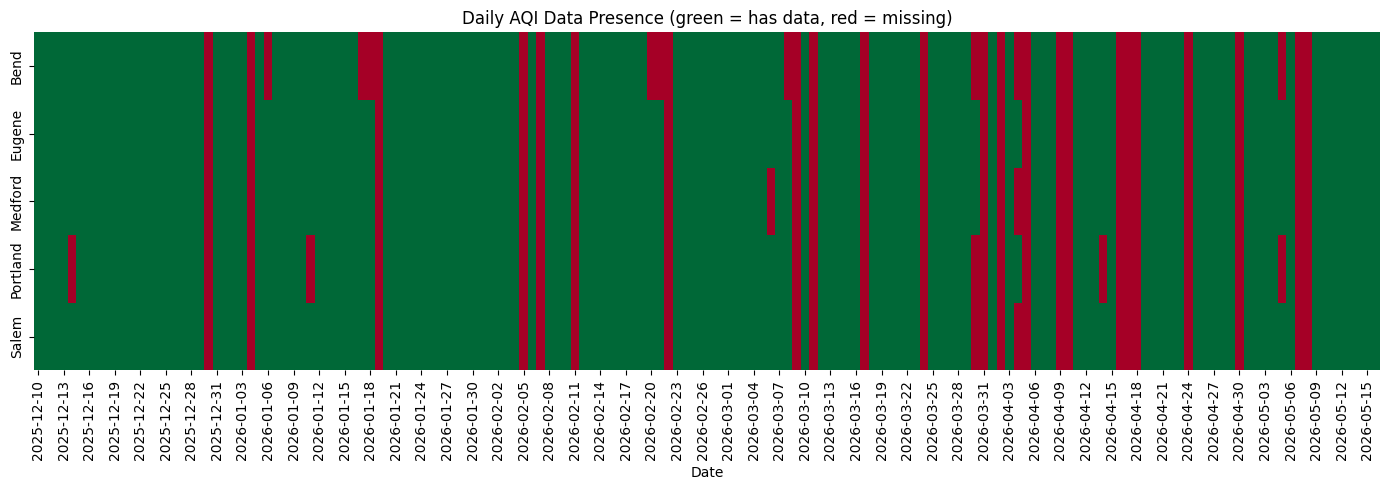

In [26]:
# Heatmap to examine where our missing values are

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot.T, cmap='RdYlGn', linewidths=0, ax=ax, cbar=False)
ax.set_title('Daily AQI Data Presence (green = has data, red = missing)')
ax.set_xlabel('Date')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. AQS Backfill

In [8]:
# Mapping AQI to category EPA standards

def aqi_to_category(aqi):
    if aqi is None:
        return None
    if 0 <= aqi <= 50:
        return "Good"
    elif 51 <= aqi <= 100:
        return "Moderate"
    elif 101 <= aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif 151 <= aqi <= 200:
        return "Unhealthy"
    elif 201 <= aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

print(aqi_to_category(32))    # Good
print(aqi_to_category(75))    # Moderate
print(aqi_to_category(None))  # None

Good
Moderate
None


In [7]:
# Function to normalize records taken from AQS API

PARAM_TO_POLLUTANT = {
      "88101": "PM2.5",
      "44201": "O3",
  }

def normalize_aqs_record(
    record: List[Dict[str, Any]],
    location_id: int
) -> List[Dict[str, Any]]:
    """
    Transform AQS records into rows matching the observations tabel schema.

    observations columns:
        location_id, timestamp_utc, aqi, category, pollutant, raw_json
    """
    normalized: List[Dict[str, Any]] = []

    for rec in record:
        aqi = rec.get("aqi")
        param_code = rec.get("parameter_code")
        pollutant = PARAM_TO_POLLUTANT.get(param_code, rec.get("parameter"))
        category = aqi_to_category(aqi)

        date_str = rec.get("date_local") # get string for date ie "2025-12-24"

        if date_str is None or aqi is None:
            continue

        dt = datetime.strptime(date_str, "%Y-%m-%d").replace(tzinfo=timezone.utc) # parse it

        already_seen = {
            (r["location_id"], r["timestamp_utc"], r["pollutant"])
            for r in normalized
        }

        key = (location_id, dt, pollutant)
        if key not in already_seen:

            normalized.append(
            {
                "location_id": location_id,
                "timestamp_utc": dt,
                "aqi": aqi,
                "category": category,
                "pollutant": pollutant,
                "raw_json": rec,
            }
        )
            
    return normalized
    

In [6]:
# Function to hit AQS API

LOCATION_COUNTY = {
      1: {"state": "41", "county": "051", "name": "Portland"},
      2: {"state": "41", "county": "039", "name": "Eugene"},
      3: {"state": "41", "county": "047", "name": "Salem"},
      4: {"state": "41", "county": "017", "name": "Bend"},
      5: {"state": "41", "county": "029", "name": "Medford"},
  }

def fetch_aqs_for_date(location_id, date_str, param_code):
    loc = LOCATION_COUNTY[location_id]  # get the dict for this location

    params = {
          "email": AQS_EMAIL,
          "key": AQS_API_KEY,
          "param": param_code,                   # you have this as a parameter
          "bdate": date_str.replace("-", ""),                   # convert date_str, remove dashes
          "edate": date_str.replace("-", ""),                   # same date (single day)
          "state": loc["state"],                   # pull from loc
          "county": loc["county"],                  # pull from loc
      }

    response = requests.get(url, params=params, timeout=10)
    data = response.json()
    records = data["Data"]

    # filter to 24-hr block average rows that have an AQI value
    filtered = [r for r in records if r['sample_duration_code'] == 'X' and r['aqi'] is not None]

    return filtered

In [4]:
# query to check which pollutants each location has

query = """
SELECT l.id, l.name, o.pollutant
FROM observations o
JOIN locations l ON o.location_id = l.id
GROUP BY l.id, l.name, o.pollutant
ORDER BY l.id;
"""
location_pollutants_df = pd.read_sql(query, engine)
location_pollutants_df

POLLUTANT_TO_PARAM = {"PM2.5": "88101", "O3": "44201"}

LOCATION_PARAMS = (
    location_pollutants_df
    .groupby("id")["pollutant"]
    .apply(lambda x: [POLLUTANT_TO_PARAM[p] for p in x])
    .to_dict()
)

LOCATION_PARAMS

{1: ['44201', '88101'],
 2: ['44201', '88101'],
 3: ['44201', '88101'],
 4: ['88101'],
 5: ['88101']}

In [12]:
# loop for fetching missing records

NAME_TO_ID = {v["name"]: k for k, v in LOCATION_COUNTY.items()}

all_normalized = []

for i, (_, row) in enumerate(missing_dates_df.iterrows()):
    location_id = NAME_TO_ID[row["name"]]
    date_str = str(row["date"])
    for param_code in LOCATION_PARAMS[location_id]:
        try:
            raw = fetch_aqs_for_date(location_id, date_str, param_code)
            normalized = normalize_aqs_record(raw, location_id)
            all_normalized.extend(normalized)
        except Exception as e:
            print(f"Skipping {row['name']} {date_str} {param_code}: {e}")
        time.sleep(1)
    if i % 10 == 0:
        print(f"Done. Collected {len(all_normalized)} records total")

print(f"Collected {len(all_normalized)} records")

Done. Collected 1 records total
Done. Collected 11 records total
Done. Collected 12 records total
Done. Collected 12 records total
Skipping Bend 2026-05-05 88101: HTTPSConnectionPool(host='aqs.epa.gov', port=443): Read timed out. (read timeout=10)
Skipping Bend 2026-05-07 88101: HTTPSConnectionPool(host='aqs.epa.gov', port=443): Read timed out. (read timeout=10)
Done. Collected 12 records total
Done. Collected 22 records total
Done. Collected 32 records total
Done. Collected 39 records total
Done. Collected 41 records total
Done. Collected 51 records total
Done. Collected 61 records total
Done. Collected 67 records total
Done. Collected 69 records total
Skipping Portland 2026-01-04 44201: HTTPSConnectionPool(host='aqs.epa.gov', port=443): Max retries exceeded with url: /data/api/dailyData/byCounty?email=stevenehowley%40gmail.com&key=saffronswift12&param=44201&bdate=20260104&edate=20260104&state=41&county=051 (Caused by ConnectTimeoutError(<HTTPSConnection(host='aqs.epa.gov', port=443) 

In [17]:
# inserting fetched missing dates into database 

insert_sql = text("""
INSERT INTO observations (location_id, timestamp_utc, aqi, category, pollutant, raw_json)
VALUES (:location_id, :timestamp_utc, :aqi, :category, :pollutant, :raw_json)
ON CONFLICT (location_id, timestamp_utc, pollutant) DO NOTHING
""")

inserted = 0
skipped = 0 

with engine.begin() as conn:
    for record in all_normalized:
        result = conn.execute(insert_sql, {
            "location_id": record["location_id"],
            "timestamp_utc": record["timestamp_utc"],
            "aqi": record["aqi"],
            "category": record["category"],
            "pollutant": record["pollutant"],
            "raw_json": json.dumps(record["raw_json"])
        })
        if result.rowcount > 0:
            inserted += 1
        else:
            skipped += 1

print(f"Inserted: {inserted}, Skipped (duplicates): {skipped}")

Inserted: 119, Skipped (duplicates): 0


## 4. Rebuild Daily Aggregates and Verify

In [21]:
# rebuild daily aggregates from new observations

import sys
sys.path.insert(0, "..")

from src.features.build_features import run_daily_aggregation

run_daily_aggregation()

Database settings:
  DB_USER = postgres
  DB_HOST = localhost
  DB_PORT = 5433
  DB_NAME = aqi_db

Building daily aggregates...
âœ… Daily aggregation complete. Rows inserted (if known): 0


In [ ]:
# verify: count remaining missing days after backfill
query = """
SELECT l.name, COUNT(*) AS missing_days
FROM generate_series(
      '2025-12-10'::date,
      '2026-05-16'::date,
      '1 day'::interval
  ) AS d(date)
CROSS JOIN locations l
LEFT JOIN daily_aggregates da
    ON da.location_id = l.id AND da.date = d.date
WHERE da.id IS NULL
GROUP BY l.name
ORDER BY missing_days DESC;
"""
pd.read_sql(query, engine)